<a href="https://colab.research.google.com/github/diipperss/DNN_GroupProject/blob/main/PartC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part C: Sentiment Analysis

---

In [1]:
pip install -q transformers datasets accelerate pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [3]:
#config
TRAIN_SIZE = 2000
VAL_SIZE = 1000
TEST_SIZE = 1000
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 1

MODEL_NAMES = [
    "distilbert-base-uncased",
    "bert-base-uncased"
]

LABEL_NAMES = ["negative", "positive"]

In [4]:
raw_data = load_dataset("imdb")

train_data = raw_data["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
valid_pool = raw_data["test"].shuffle(seed=SEED)
val_data = valid_pool.select(range(VAL_SIZE))
test_data = valid_pool.select(range(VAL_SIZE, VAL_SIZE + TEST_SIZE))

print(train_data)
print(val_data)
print(test_data)

Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})


In [5]:
def tokenize_dataset(dataset, tokenizer):
    def tokenize(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN
        )

    tokenized = dataset.map(tokenize, batched=True)
    tokenized = tokenized.remove_columns(["text"])
    tokenized = tokenized.rename_column("label", "labels")
    tokenized.set_format("torch")
    return tokenized


def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

In [8]:
def make_training_args(output_dir):
    args = {
        "output_dir": output_dir,
        "save_strategy": "epoch",
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
        "learning_rate": 2e-5,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": BATCH_SIZE,
        "num_train_epochs": EPOCHS,
        "weight_decay": 0.01,
        "logging_steps": 50,
        "report_to": [],
        "fp16": torch.cuda.is_available(),
        "seed": SEED,
        "disable_tqdm": False,
    }

    try:
        return TrainingArguments(eval_strategy="epoch", **args)
    except TypeError:
        return TrainingArguments(evaluation_strategy="epoch", **args)


def train_transformer(model_name):
    print("Training:", model_name)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = tokenize_dataset(train_data, tokenizer)
    val_dataset = tokenize_dataset(val_data, tokenizer)
    test_dataset = tokenize_dataset(test_data, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    trainer = Trainer(
        model=model,
        args=make_training_args("./results_" + model_name.replace("/", "_")),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    # Work around Trainer.evaluate() notebook-callback bug by using predict()
    val_predictions = trainer.predict(val_dataset)
    val_pred = np.argmax(val_predictions.predictions, axis=1)
    val_true = val_predictions.label_ids

    test_predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(test_predictions.predictions, axis=1)
    y_true = test_predictions.label_ids

    return {
        "model_name": model_name,
        "tokenizer": tokenizer,
        "model": trainer.model,
        "trainer": trainer,
        "test_dataset": test_dataset,
        "y_true": y_true,
        "y_pred": y_pred,
        "val_accuracy": accuracy_score(val_true, val_pred),
        "val_f1": f1_score(val_true, val_pred),
        "test_accuracy": accuracy_score(y_true, y_pred),
        "test_f1": f1_score(y_true, y_pred),
    }

In [9]:
results = []

for model_name in MODEL_NAMES:
    result = train_transformer(model_name)
    results.append(result)

summary = pd.DataFrame([
    {
        "model": r["model_name"],
        "val_accuracy": r["val_accuracy"],
        "val_f1": r["val_f1"],
        "test_accuracy": r["test_accuracy"],
        "test_f1": r["test_f1"],
    }
    for r in results
]).sort_values(by="test_f1", ascending=False).reset_index(drop=True)

summary

Training: distilbert-base-uncased


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 14557.49it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.499021,0.422564,0.828000,0.828685


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.77it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10093.07it/s]
BertForSequenceClassification

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.473755,0.412882,0.830000,0.834308


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.17it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,model,val_accuracy,val_f1,test_accuracy,test_f1
0,bert-base-uncased,0.830,0.834308,0.831,0.841612
1,distilbert-base-uncased,0.828,0.828685,0.823,0.828986


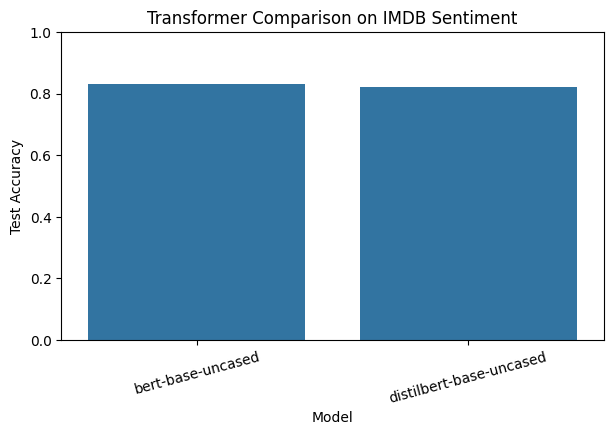

In [10]:
plt.figure(figsize=(7, 4))
sns.barplot(data=summary, x="model", y="test_accuracy")
plt.ylim(0, 1)
plt.title("Transformer Comparison on IMDB Sentiment")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=15)
plt.show()

Best model: bert-base-uncased


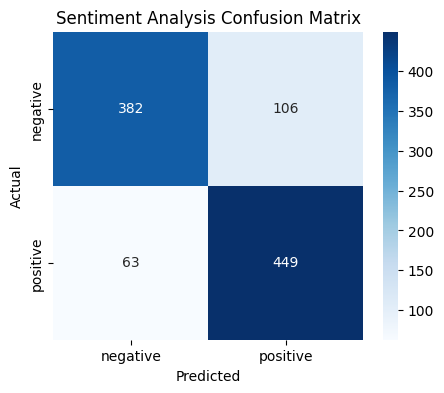

              precision    recall  f1-score   support

    negative       0.86      0.78      0.82       488
    positive       0.81      0.88      0.84       512

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



In [11]:
if "results" not in globals() or len(results) == 0:
    raise RuntimeError("Run Cell 10 first to train the models and create results.")

best_result = max(results, key=lambda x: x["test_f1"])
print("Best model:", best_result["model_name"])

cm = confusion_matrix(best_result["y_true"], best_result["y_pred"])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES
)
plt.title("Sentiment Analysis Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(
    best_result["y_true"],
    best_result["y_pred"],
    target_names=LABEL_NAMES
))

In [12]:
def predict_sentiment(text):
    if "best_result" not in globals():
        raise RuntimeError("Run Cell 11 first so best_result is defined.")

    tokenizer = best_result["tokenizer"]
    model = best_result["model"].to(device)
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LEN
    )
    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)[0]
        pred = torch.argmax(probs).item()

    return LABEL_NAMES[pred], probs[pred].item()

print(predict_sentiment("The movie was surprisingly emotional and beautifully acted."))
print(predict_sentiment("The story was boring and the ending was disappointing."))

('positive', 0.892989456653595)
('negative', 0.7538025975227356)
